In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn import metrics

# Membaca file CSV
df = pd.read_csv('Jahe Kering Mix 1.csv', header=0)

names = df.columns.tolist()
# Memisahkan kolom menjadi target dan fitur
y = df.iloc[:, 0]  # target Agtron
X = df.iloc[:,1:]  # fitur
import sklearn
print(sklearn.__version__)

1.6.1


In [2]:
# shape
print(names)
print(X.shape)
print(y.shape)
print(X.head(5))
print(y.head(5))

['6 Gingerol', '410', '435', '460', '485', '510', '535', '560', '585', '610', '645', '680', '705', '730', '760', '810', '860', '900', '940']
(180, 18)
(180,)
       410     435      460     485      510      535     560     585  \
0  2772.42  956.78  3520.05  627.15  2035.72  2900.54  276.33  298.53   
1  2793.22  952.49  3522.25  932.61  2042.09  2927.99  262.01  281.55   
2  2918.40  991.84  3711.13  951.23  2102.03  3047.62  235.33  252.19   
3  4075.15  626.72  1474.88  681.71   972.24   879.03  166.35  164.12   
4  1183.68  510.58  2148.78  773.71  1379.69  2117.86  503.91  512.75   

       610     645      680    705     730     760      810      860     900  \
0  1667.55  208.79   785.00  73.96  222.53  141.34   289.94   884.68  483.45   
1  1722.05  198.35   816.21  70.19  230.72  147.96   301.24   921.17  535.60   
2  1664.49  177.23   802.23  64.39  225.07  145.75   305.01   935.82  509.53   
3  3443.54  118.38  1223.69  51.35  344.62  209.60  1128.48  3070.10  917.94   
4  

In [3]:
# split data kalibrasi (70%) dan validasi (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
import numpy as np
# Standardize features (optional but can be beneficial for some models)
scaler = StandardScaler()

# Fix: Convert columns with commas to numeric type by replacing commas first
# Iterate through columns and convert object type (string) columns to float
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = X_train[col].astype(str).str.replace(',', '').astype(float)
for col in X_test.columns:
    if X_test[col].dtype == 'object':
        X_test[col] = X_test[col].astype(str).str.replace(',', '').astype(float)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi dan Trial Pemodelan
# Multiple Linear Regression
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)
lr_pred = linear_reg_model.predict(X_test_scaled)

# Random Forest Regression
random_forest_model = RandomForestRegressor(max_depth= 20, max_features= 3, min_samples_leaf= 1, n_estimators= 50)
random_forest_model.fit(X_train, y_train)
rf_pred = random_forest_model.predict(X_test)

# XGBoost Regression
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Evaluate models
linear_reg_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
random_forest_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"Linear Regression RMSE: {linear_reg_rmse}")
print(f"Random Forest RMSE: {random_forest_rmse}")
print(f"XGBoost RMSE: {xgb_rmse}")

# Function to calculate RPD
def calculate_rpd(y_true, y_pred):
    std_dev = y_true.std()
    rpd = std_dev / np.sqrt(mean_squared_error(y_true, y_pred))
    return rpd

# Evaluate models
linear_reg_r2 = r2_score(y_test, lr_pred)
random_forest_r2 = r2_score(y_test, rf_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

linear_reg_rpd = calculate_rpd(y_test, lr_pred)
random_forest_rpd = calculate_rpd(y_test, rf_pred)
xgb_rpd = calculate_rpd(y_test, xgb_pred)

print(f"Linear Regression R2: {linear_reg_r2}")
print(f"Random Forest R2: {random_forest_r2}")
print(f"XGBoost R2: {xgb_r2}")

print(f"Linear Regression RPD: {linear_reg_rpd}")
print(f"Random Forest RPD: {random_forest_rpd}")
print(f"XGBoost RPD: {xgb_rpd}")

Linear Regression RMSE: 0.8723479556795556
Random Forest RMSE: 0.5120411731564246
XGBoost RMSE: 0.6115559861655224
Linear Regression R2: 0.1641388451288176
Random Forest R2: 0.7120186155452005
XGBoost R2: 0.5892031634657353
Linear Regression RPD: 1.1040579613464896
Random Forest RPD: 1.8809477753425141
XGBoost RPD: 1.574872501160787


In [5]:
#Cross-validation dan hyperparameter tuning
linear = LinearRegression()
linear_training = linear.fit(X_train, y_train).predict(X_train)

# Define 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get predictions on training data
lr_cv = cross_val_score(linear, X_train, y_train, cv=kf)

print(f'Mean R² (CV): {np.mean(lr_cv):.3f}')
print(f'Standard Deviation R² (CV): {np.std(lr_cv):.3f}')

print('Training')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, linear_training))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, linear_training))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, linear_training)))
print('R^2:', r2_score(y_train, linear_training))
print('Validation')
linear_predictions = linear.predict(X_test)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, linear_predictions))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, linear_predictions))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, linear_predictions)))
print('R^2:', r2_score(y_test, linear_predictions))

Mean R² (CV): 0.040
Standard Deviation R² (CV): 0.185
Training
Mean Absolute Error: 0.801144923980929
Mean Squared Error: 0.939327441622013
Root Mean Squared Error: 0.9691890639199418
R^2: 0.32163144340286276
Validation
Mean Absolute Error: 0.697825890453421
Mean Squared Error: 0.7609909557782992
Root Mean Squared Error: 0.8723479556795553
R^2: 0.16413884512881816


In [6]:
#Ekstrak koefisien regresi MLR (asli) tanpa standarisasi data
coefficients = linear.coef_
intercept = linear.intercept_

print("Coefficients:", coefficients)
print("Intercept:", intercept)

Coefficients: [ 4.34390837e-04 -1.50919405e-03 -6.31256183e-04 -2.87018234e-04
  1.17701789e-03  3.15175776e-05 -8.14340945e-03  1.18700791e-02
 -2.04473400e-04 -8.99522824e-03  4.95655621e-03 -2.61393809e-03
  5.90131437e-03 -2.88339686e-02 -4.13694915e-05 -1.19871301e-04
  4.45537688e-03 -1.61732641e-02]
Intercept: 5.123240490889219


In [7]:
#Cross-validation dan hyperparameter tuning RF
param_grid2 = {
     'max_depth': [None, 5, 10, 20],
    'max_features': [None, 1, 3, 5, 0.5],
    'min_samples_leaf': [1,2,5,10],
    'n_estimators': [50, 100, 200]
}
grid2 = GridSearchCV(random_forest_model, param_grid2, scoring='r2', n_jobs= -1, cv=5)
grid2.fit(X_train, y_train)

print(grid2.best_params_)

# Reuse the best model found by GridSearchCV
best_rf = grid2.best_estimator_

rf_cv = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'Mean R² (CV): {np.mean(rf_cv):.3f}')
print(f'Standard Deviation R² (CV): {np.std(rf_cv):.3f}')

grid2_training = grid2.predict(X_train)
print('Training')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, grid2_training))
print('Mean Squared Error:', metrics.mean_squared_error(y_train, grid2_training))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, grid2_training)))
print('R^2:', r2_score(y_train, grid2_training))
print('Validation')
grid2_predictions = grid2.predict(X_test)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, grid2_predictions))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, grid2_predictions))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, grid2_predictions)))
print('R^2:', r2_score(y_test, grid2_predictions))

{'max_depth': None, 'max_features': 5, 'min_samples_leaf': 1, 'n_estimators': 50}
Mean R² (CV): 0.561
Standard Deviation R² (CV): 0.164
Training
Mean Absolute Error: 0.2260567460317463
Mean Squared Error: 0.09122094402777801
Root Mean Squared Error: 0.3020280517233093
R^2: 0.9341215667832546
Validation
Mean Absolute Error: 0.3585851851851852
Mean Squared Error: 0.22084419962962987
Root Mean Squared Error: 0.4699406341546024
R^2: 0.7574280136348919


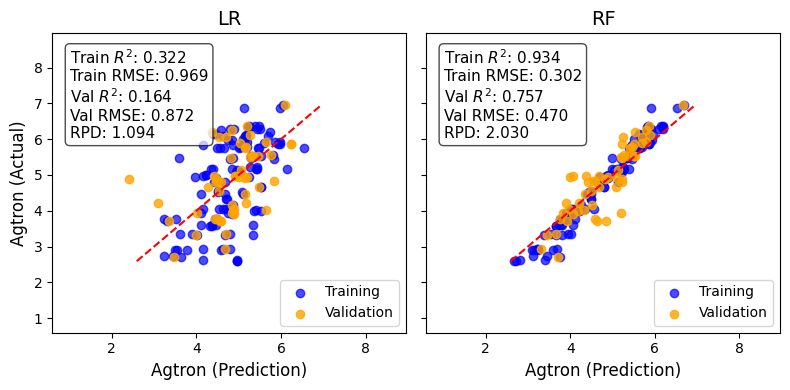

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Fungsi untuk menghitung metrik evaluasi
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rpd = np.std(y_true) / rmse
    return r2, rmse, rpd

# Hitung metrik untuk setiap model (training dan validasi)
metrics_lr_train = calculate_metrics(y_train, linear_training)
metrics_lr_val = calculate_metrics(y_test, linear_predictions)

metrics_rf_train = calculate_metrics(y_train, grid2_training)
metrics_rf_val = calculate_metrics(y_test, grid2_predictions)

# Fungsi untuk plotting dengan metrik
def plot_with_metrics(ax, y_train_pred, y_train_true, y_val_pred, y_val_true, title, metrics_train, metrics_val):
    # Plot data training (biru)
    ax.scatter(y_train_pred, y_train_true, alpha=0.7, color='blue', label='Training')
    # Plot data validasi (oranye)
    ax.scatter(y_val_pred, y_val_true, alpha=0.8, color='orange', label='Validation')
    # Garis ideal
    min_val = min(np.min(y_train_true), np.min(y_val_true))
    max_val = max(np.max(y_train_true), np.max(y_val_true))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Agtron (Prediction)', fontsize=12)
    ax.set_xlim(min_val - 2, max_val + 2)
    ax.set_ylim(min_val - 2, max_val + 2)

    # Tampilkan metrik
    ax.text(0.05, 0.95, f"Train $R^2$: {metrics_train[0]:.3f}\nTrain RMSE: {metrics_train[1]:.3f}"
                        f"\nVal $R^2$: {metrics_val[0]:.3f}\nVal RMSE: {metrics_val[1]:.3f}"
                        f"\nRPD: {metrics_val[2]:.3f}",
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    ax.legend(loc='lower right')

# Buat subplots
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

# Plot masing-masing model
plot_with_metrics(axs[0], linear_training, y_train, linear_predictions, y_test, 'LR', metrics_lr_train, metrics_lr_val)
axs[0].set_ylabel('Agtron (Actual)', fontsize=12)

plot_with_metrics(axs[1], grid2_training, y_train, grid2_predictions, y_test, 'RF', metrics_rf_train, metrics_rf_val)

plt.tight_layout()
plt.show()

Coefficients: [ 0.36555452 -0.35115474 -0.57788869 -0.07102145  0.59595802  0.02448036
 -1.11983452  1.77990535 -0.23222557 -0.848124    1.47370919 -0.079714
  0.5482099  -1.46982773 -0.01000384 -0.07895475  0.97076549 -1.09804565]
Intercept: 4.83404761904762


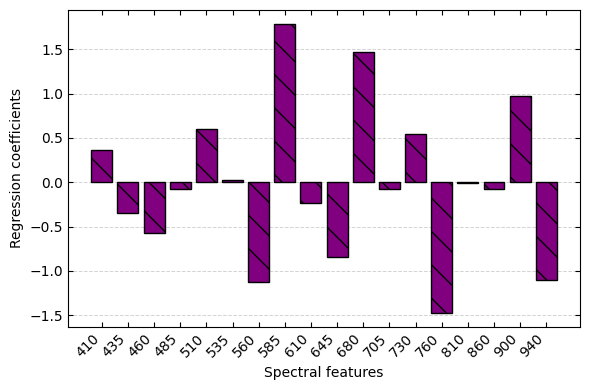

In [9]:
#plot nilai koefisien regresi MLR yang distandarisasi
import matplotlib.pyplot as plt
# Standardize features (optional but can be beneficial for some models)
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train)
X_test_scaled2 = scaler2.transform(X_test)
# Multiple Linear Regression
lr= LinearRegression()
lr.fit(X_train_scaled2, y_train)
lr_pred = lr.predict(X_test_scaled2)
coef = lr.coef_
intercept2 = lr.intercept_

print("Coefficients:", coef)
print("Intercept:", intercept2)
# Membuat plot koefisien
plt.figure(figsize=(6, 4))
bars = plt.bar(X.columns, coef, color='purple', edgecolor='black', hatch='\\')  # warna dan pattern
plt.xlabel('Spectral features')
plt.ylabel('Regression coefficients')
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.grid(axis='y', linestyle='--', color='lightgray', linewidth=0.7)
plt.gca().set_axisbelow(True)  # supaya grid ada di belakang batang
plt.tight_layout()
plt.show()